In [22]:
from google.colab import files
import io

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

Saving compas_prepared.csv to compas_prepared (2).csv


In [23]:
# ── Setup e carga ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import pickle

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv(file_name)

print(f"Shape: {df.shape}")
df.head()

Shape: (4610, 13)


,sex,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid,sex_encoded,c_charge_degree_encoded,race_encoded,age_cat_encoded
0,Male,25 - 45,African-American,0,0,0,0,F,1,1,1,1,1
1,Male,Less than 25,African-American,0,0,1,4,F,1,1,1,1,0
2,Male,Less than 25,African-American,0,1,0,1,F,0,1,1,1,0
3,Male,25 - 45,Caucasian,0,0,0,14,F,1,1,1,0,1
4,Female,25 - 45,Caucasian,0,0,0,0,M,0,0,0,0,1


In [24]:
# ── Features e target ──────────────────────────────────

FEATURES = [
    'sex_encoded',
    'age_cat_encoded',
    'race_encoded',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'priors_count',
    'c_charge_degree_encoded',
]

# Colunas numéricas que precisam de scaling
NUMERIC_FEATURES = [
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'priors_count',
]

TARGET = 'two_year_recid'

X = df[FEATURES]
y = df[TARGET]
race = df['race']  # mantido separado para métricas de viés

print(f"Features: {FEATURES}")
print(f"\nShape X: {X.shape}")
print(f"Balanceamento target:\n{y.value_counts(normalize=True).mul(100).round(2)}")

Features: ['sex_encoded', 'age_cat_encoded', 'race_encoded', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree_encoded']

Shape X: (4610, 8)
Balanceamento target:
two_year_recid
0    52.43
1    47.57
Name: proportion, dtype: float64


In [25]:
# ── Split e scaling ─────────────────────────────────────

X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# StandardScaler apenas nas colunas numéricas
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"\nBalanceamento treino:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"\nBalanceamento teste:\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

Treino: (3688, 8) | Teste: (922, 8)

Balanceamento treino:
two_year_recid
0    52.44
1    47.56
Name: proportion, dtype: float64

Balanceamento teste:
two_year_recid
0    52.39
1    47.61
Name: proportion, dtype: float64


In [26]:
# ── Tuning ampliado ─────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
import warnings
warnings.filterwarnings('ignore')

param_dist = {
    # Região ao redor do ótimo anterior (C=0.001) com mais granularidade
    'C'            : [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
    'penalty'      : ['l1', 'l2', 'elasticnet'],
    'solver'       : ['saga'],          # saga suporta l1, l2 e elasticnet
    'l1_ratio'     : [0.1, 0.3, 0.5, 0.7, 0.9],  # só usado no elasticnet
    'class_weight' : [None, 'balanced', {0:1, 1:2}, {0:1, 1:3}],
    'tol'          : [1e-4, 1e-3, 1e-2],
    'max_iter'     : [1000, 2000, 5000],
}

random_search = RandomizedSearchCV(
    estimator  = LogisticRegression(random_state=42),
    param_distributions = param_dist,
    n_iter     = 60,
    scoring    = 'roc_auc',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1,
    random_state = 42,
    return_train_score = True    # necessário para análise completa
)

random_search.fit(X_train, y_train)

print(f"Melhores hiperparâmetros: {random_search.best_params_}")
print(f"Melhor ROC-AUC (cv):      {random_search.best_score_:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores hiperparâmetros: {'tol': 0.0001, 'solver': 'saga', 'penalty': 'elasticnet', 'max_iter': 1000, 'l1_ratio': 0.1, 'class_weight': None, 'C': 0.005}
Melhor ROC-AUC (cv):      0.7246


In [27]:
# ── Avaliação do melhor modelo ─────────────────────────

model = random_search.best_estimator_

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== DESEMPENHO GERAL ===")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

=== DESEMPENHO GERAL ===

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.80      0.72       483
           1       0.71      0.54      0.61       439

    accuracy                           0.67       922
   macro avg       0.68      0.67      0.66       922
weighted avg       0.68      0.67      0.67       922



In [28]:
# ── CÉLULA 6 · Métricas de performance ────────────────────────────

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report, ConfusionMatrixDisplay)

metrics = {
    'Acurácia'  : accuracy_score(y_test, y_pred),
    'Precisão'  : precision_score(y_test, y_pred),
    'Recall'    : recall_score(y_test, y_pred),
    'F1-Score'  : f1_score(y_test, y_pred),
    'ROC-AUC'   : roc_auc_score(y_test, y_prob),
}

print("=== MÉTRICAS DE PERFORMANCE ===")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

=== MÉTRICAS DE PERFORMANCE ===
  Acurácia: 0.6725
  Precisão: 0.7057
  Recall: 0.5353
  F1-Score: 0.6088
  ROC-AUC: 0.7202


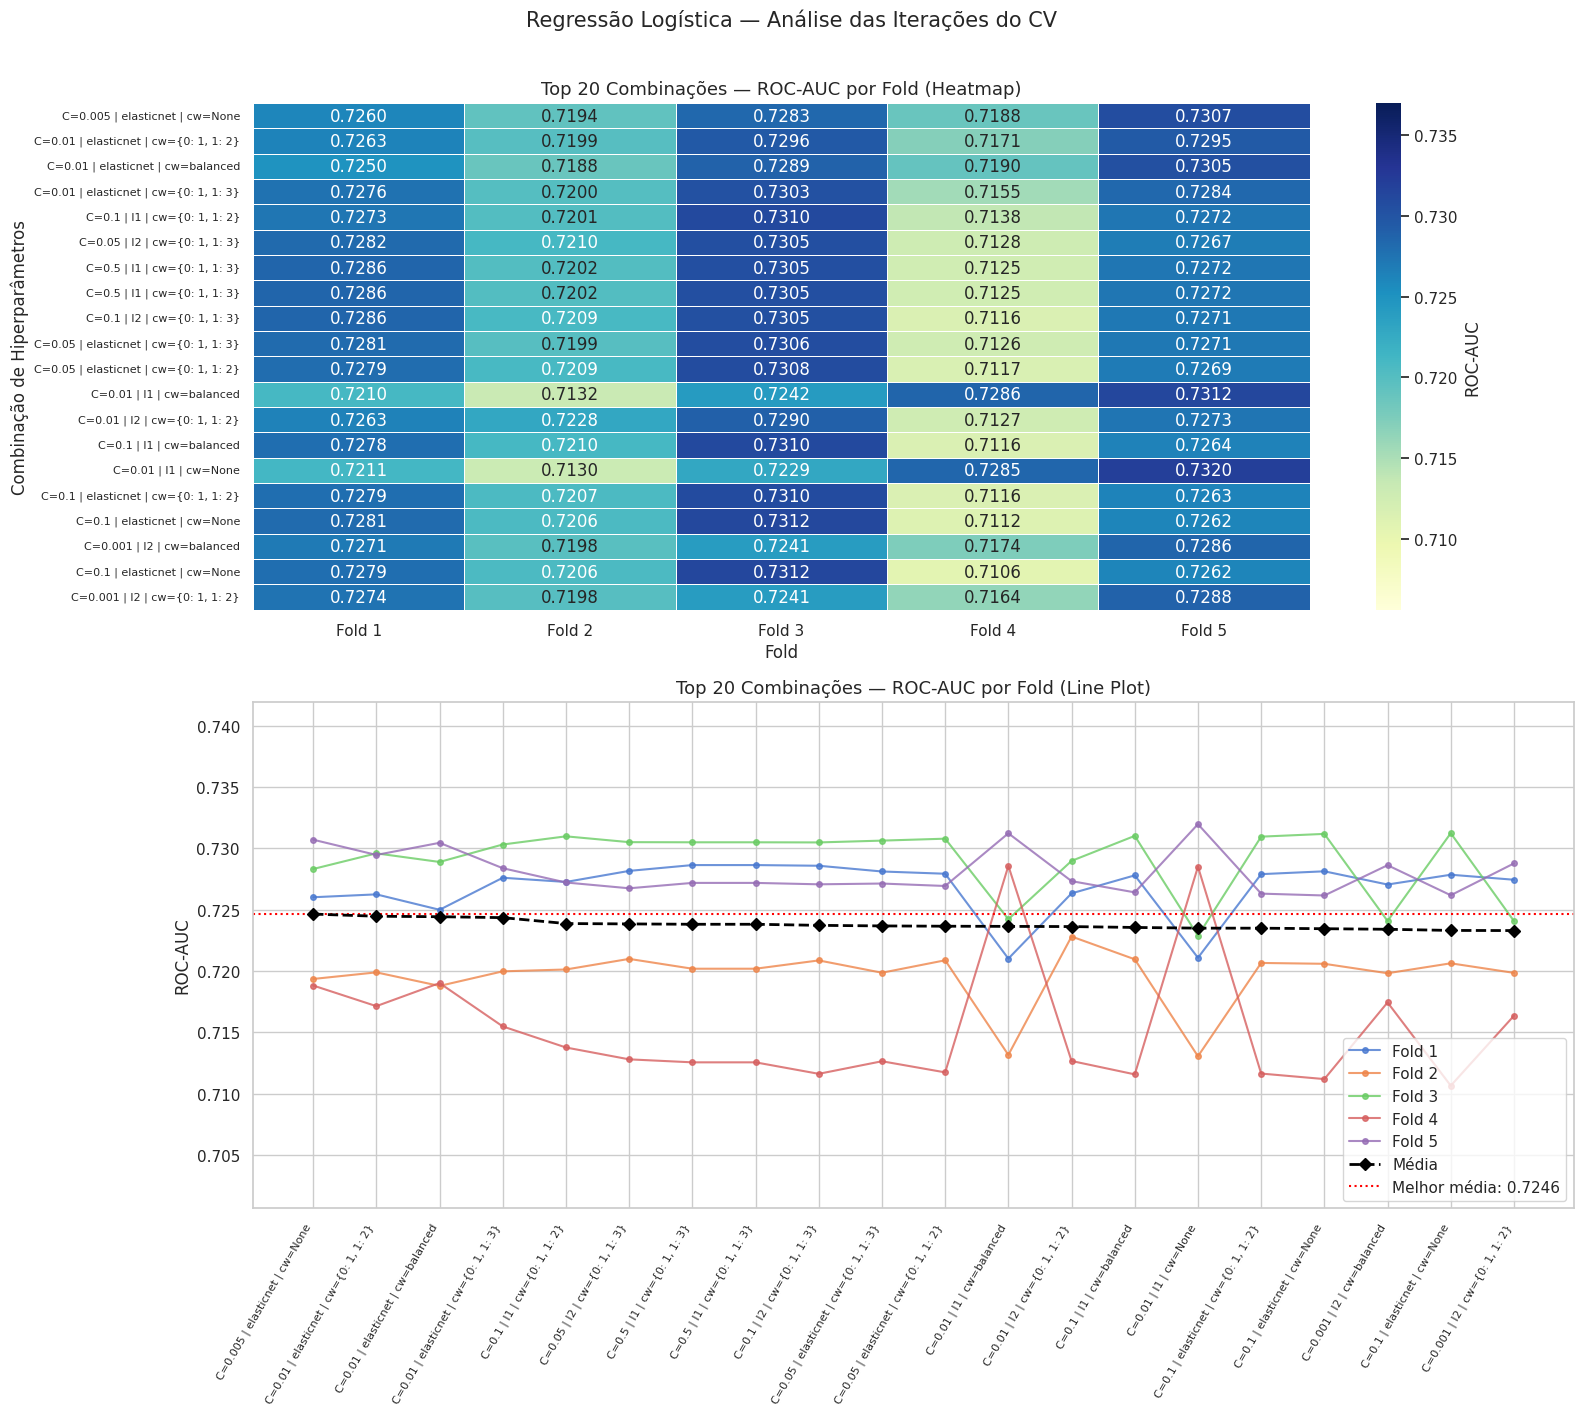

In [29]:
# ── Iterações do CV ────────────────────────────────────

cv_results = pd.DataFrame(random_search.cv_results_)
fold_cols  = [f'split{i}_test_score' for i in range(5)]

# Top 20 combinações por ROC-AUC médio
top20 = (cv_results
         .nlargest(20, 'mean_test_score')
         .reset_index(drop=True))

top20['label'] = top20.apply(
    lambda r: f"C={r['param_C']} | {r['param_penalty']} | cw={r['param_class_weight']}",
    axis=1
)

# Matriz de scores: 20 combinações x 5 folds
scores_matrix = top20[fold_cols].values

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# 7a. Heatmap — combinações x folds
heatmap_data = pd.DataFrame(
    scores_matrix,
    index=top20['label'],
    columns=[f'Fold {i+1}' for i in range(5)]
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=axes[0],
    vmin=scores_matrix.min() - 0.005,
    vmax=scores_matrix.max() + 0.005,
    cbar_kws={'label': 'ROC-AUC'}
)
axes[0].set_title('Top 20 Combinações — ROC-AUC por Fold (Heatmap)', fontsize=13)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Combinação de Hiperparâmetros')
axes[0].tick_params(axis='y', labelsize=8)

# 7b. Line plot — comportamento de cada fold
fold_colors = sns.color_palette('muted', 5)
x = range(len(top20))

for i, (fold_col, color) in enumerate(zip(fold_cols, fold_colors)):
    axes[1].plot(x, top20[fold_col].values,
                 marker='o', markersize=4,
                 label=f'Fold {i+1}',
                 color=color, linewidth=1.5, alpha=0.8)

# Média em destaque
axes[1].plot(x, top20['mean_test_score'].values,
             marker='D', markersize=6,
             label='Média', color='black',
             linewidth=2, linestyle='--', zorder=5)

axes[1].axhline(y=random_search.best_score_, color='red',
                linestyle=':', linewidth=1.5,
                label=f'Melhor média: {random_search.best_score_:.4f}')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top20['label'], rotation=60, ha='right', fontsize=8)
axes[1].set_title('Top 20 Combinações — ROC-AUC por Fold (Line Plot)', fontsize=13)
axes[1].set_ylabel('ROC-AUC')
axes[1].legend(loc='lower right')
axes[1].set_ylim(scores_matrix.min() - 0.01, scores_matrix.max() + 0.01)

plt.suptitle('Regressão Logística — Análise das Iterações do CV', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('/content/lr_cv_iterations.png', dpi=150, bbox_inches='tight')
plt.show()

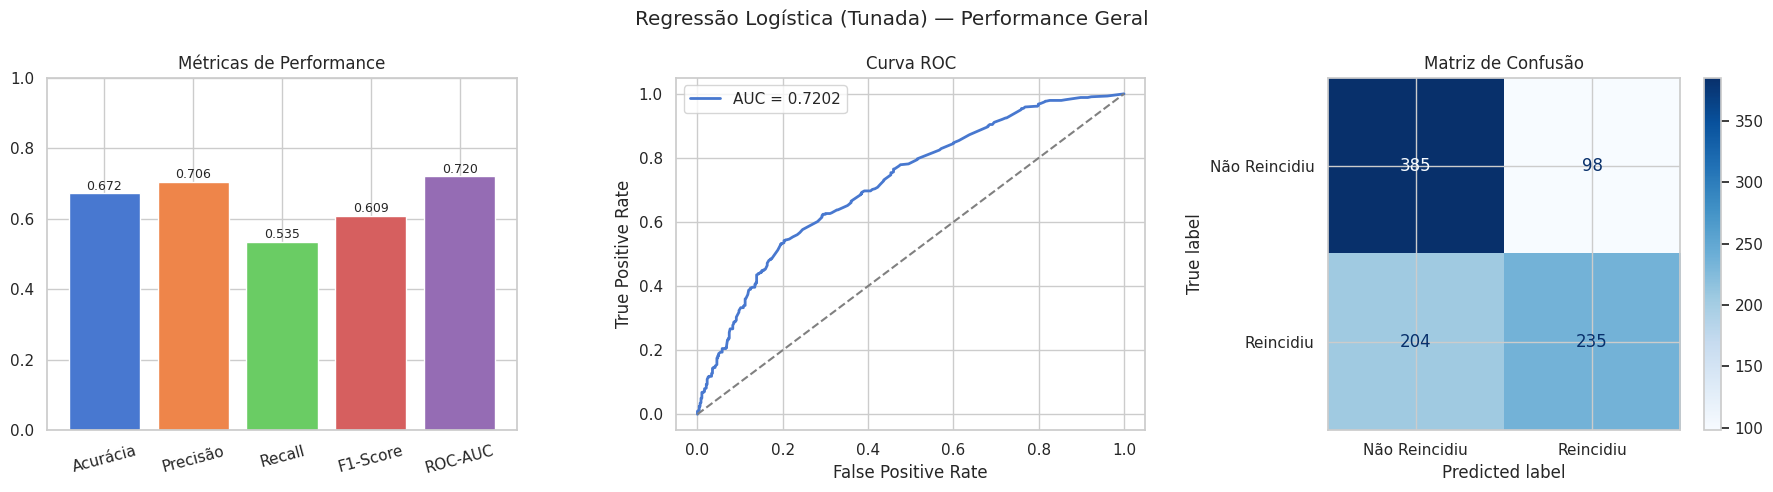

In [30]:
# ── Visualizações de performance ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 8a. Métricas em barras
axes[0].bar(metrics.keys(), metrics.values(), color=sns.color_palette('muted'))
axes[0].set_title('Métricas de Performance')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(metrics.values()):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# 8b. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#4878CF', lw=2,
             label=f"AUC = {metrics['ROC-AUC']:.4f}")
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 8c. Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Não Reincidiu', 'Reincidiu'],
    cmap='Blues',
    ax=axes[2]
)
axes[2].set_title('Matriz de Confusão')

plt.suptitle('Regressão Logística (Tunada) — Performance Geral')
plt.tight_layout()
plt.savefig('/content/lr_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ── CÉLULA 8 · Exportar modelo e resultados ────────────────────────

# Modelo e scaler
with open('/content/lr_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('/content/lr_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Métricas
df_metrics = pd.DataFrame([{
    'modelo'    : 'LogisticRegression',
    'subsample' : '100pct',
    'acuracia'  : metrics['Acurácia'],
    'precisao'  : metrics['Precisão'],
    'recall'    : metrics['Recall'],
    'f1'        : metrics['F1-Score'],
    'roc_auc'   : metrics['ROC-AUC'],
}])

df_metrics.to_csv('/content/lr_results.csv', index=False)

print("Exportados:")
print("   lr_model.pkl")
print("   lr_scaler.pkl")
print("   lr_results.csv")
print(f"\n{df_metrics.to_string(index=False)}")

Exportados:
   lr_model.pkl
   lr_scaler.pkl
   lr_results.csv

            modelo subsample  acuracia  precisao   recall       f1  roc_auc
LogisticRegression    100pct  0.672451  0.705706 0.535308 0.608808 0.720207
